In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost.callback import EarlyStopping
from sklearn.model_selection import RandomizedSearchCV

In [2]:
# df = pd.read_csv("data_processed/final_for_prediction/final_model_data/final_data.csv")
# df.head()

In [3]:
from Pipeline.main_data import EVFullPipeline

In [3]:
main_pipeline = EVFullPipeline()
main_pipeline.run_state("OR", "41")

2026-02-25 19:59:38,186 - INFO - Processing OR
2026-02-25 19:59:44,404 - WARNING - Skipping field funding_sources: unsupported OGR type: 5
2026-02-25 19:59:44,404 - WARNING - Skipping field ev_connector_types: unsupported OGR type: 5
2026-02-25 19:59:49,608 - INFO - Allocating ZBP to tracts
/Users/sanjeebadhikari/miniconda3/envs/ev_gap_env/lib/python3.12/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 19845 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)
2026-02-25 20:00:04,930 - INFO - Created 1,001 records
2026-02-25 20:00:04,942 - INFO - OR dataset saved.


,GEOID,geometry,population,households,median_income,workers,vehicles_total,mean_commute_time,l2_ports,dcfc_ports,total_ports,station_count,dist_nearest_charger_km,dist_nearest_dcfc_km,establishments_total,retail_establishments,food_establishments,service_establishments
0,41019100000,"POLYGON ((-123.20256 43.31449, -123.20254 43.3...",3283.0,1286.0,70978.0,1289.0,1286.0,1025.0,4.0,0.0,4.0,1.0,3.816281,63.517511,561.503363,97.635401,99.177030,107.602533
1,41053020306,"POLYGON ((-123.36479 44.83828, -123.36469 44.8...",2006.0,762.0,114231.0,1027.0,762.0,806.0,0.0,0.0,0.0,0.0,6.695750,6.695750,689.401235,67.646898,140.530871,98.175339
2,41053005204,"POLYGON ((-123.1152 44.92904, -123.11468 44.92...",4419.0,1525.0,102462.0,2021.0,1525.0,1529.0,2.0,0.0,2.0,1.0,1.902479,3.588832,66.182090,4.522137,6.722096,15.858035
3,41019180000,"POLYGON ((-123.37282 43.07053, -123.37278 43.0...",4675.0,1921.0,61515.0,2241.0,1921.0,1783.0,2.0,0.0,2.0,1.0,13.396524,20.329860,362.289205,107.078644,62.042235,75.974000
4,41019200000,"POLYGON ((-123.51076 42.91495, -123.51075 42.9...",4912.0,2135.0,47842.0,1958.0,2135.0,1368.0,2.0,20.0,22.0,3.0,6.388468,6.388468,145.701746,30.409285,27.937215,8.487941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,41029000502,"POLYGON ((-122.87362 42.34114, -122.87347 42.3...",5803.0,2411.0,45763.0,2388.0,2411.0,1949.0,3.0,0.0,3.0,2.0,0.532074,2.097752,155.228019,16.104796,15.149615,24.523717
997,41029001002,"POLYGON ((-122.94275 42.40606, -122.94245 42.4...",4790.0,1692.0,67240.0,2487.0,1692.0,2303.0,1.0,0.0,1.0,1.0,1.531800,2.276388,51.706158,5.855916,4.004181,9.227025
998,41029000403,"POLYGON ((-122.84579 42.34322, -122.84579 42.3...",4381.0,1785.0,101932.0,1812.0,1785.0,1364.0,1.0,0.0,1.0,1.0,0.955626,3.365811,196.673225,20.404706,19.194496,31.071443
999,41029000405,"POLYGON ((-122.87443 42.34684, -122.86913 42.3...",4414.0,1611.0,63854.0,2372.0,1611.0,2023.0,2.0,0.0,2.0,1.0,0.801297,1.325381,122.598894,12.719548,11.965147,19.368801


In [4]:
from Pipeline.additional_data import EVAdditionalFeaturesPipeline

In [4]:
additional_pipeline = EVAdditionalFeaturesPipeline()
additional_pipeline.run_state("OR")

2026-02-25 19:22:47,061 - INFO - Processing OR
2026-02-25 19:22:53,061 - INFO - Downloading: https://lehd.ces.census.gov/data/lodes/LODES8/or/wac/or_wac_S000_JT00_2021.csv.gz
2026-02-25 19:22:54,795 - INFO - Download complete.
2026-02-25 19:22:54,887 - INFO - Downloading: https://edg.epa.gov/data/public/OA/EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv
2026-02-25 19:24:18,544 - INFO - Download complete.
/Users/sanjeebadhikari/Downloads/Practicum/GAP ANALYSIS/additional_data.py:224: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  smart["GEOID"] = (
2026-02-25 19:24:23,136 - INFO - Created 992 records
2026-02-25 19:24:23,153 - INFO - OR dataset saved.


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,pct_work_from_home,jobs_total,high_wage_jobs,high_wage_share,D1A,D3B,D4A,D1C,D2A_JPHH,NatWalkInd
0,41,019,100000,41019100000,1000,Census Tract 1000,G5020,S,2972506997,16731802,...,0.087266,823.0,471.0,0.572296,0.024468,1.510645,NaN,0.010222,0.416389,4.555556
1,41,053,020306,41053020306,203.06,Census Tract 203.06,G5020,S,220829030,1880612,...,0.206693,314.0,161.0,0.512739,NaN,NaN,NaN,NaN,NaN,NaN
2,41,053,005204,41053005204,52.04,Census Tract 52.04,G5020,S,4002467,570220,...,0.222674,618.0,169.0,0.273463,NaN,NaN,NaN,NaN,NaN,NaN
3,41,019,180000,41019180000,1800,Census Tract 1800,G5020,S,349582103,20841,...,0.099495,498.0,187.0,0.375502,1.118011,53.121243,286.553333,0.549948,0.309942,10.166667
4,41,019,200000,41019200000,2000,Census Tract 2000,G5020,S,244952194,240125,...,0.137453,2421.0,1366.0,0.564230,0.466440,25.987901,286.330000,0.580610,1.308112,9.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,41,029,000502,41029000502,5.02,Census Tract 5.02,G5020,S,2492808,0,...,0.087547,4796.0,2257.0,0.470601,4.525540,133.194460,229.330000,9.094598,1.987842,15.166667
997,41,029,001002,41029001002,10.02,Census Tract 10.02,G5020,S,3408282,0,...,0.033571,1557.0,866.0,0.556198,4.136794,170.054333,259.733333,4.979187,1.294052,15.833333
998,41,029,000403,41029000403,4.03,Census Tract 4.03,G5020,S,3158376,0,...,0.203736,388.0,126.0,0.324742,2.601768,71.550104,955.550000,0.409640,0.180773,11.666667
999,41,029,000405,41029000405,4.05,Census Tract 4.05,G5020,S,1968819,0,...,0.064725,1467.0,629.0,0.428766,3.994286,130.837477,630.995000,3.049925,0.746886,15.500000


In [5]:
from Pipeline.merging_data import EVMasterMergePipeline

In [5]:
merge_pipeline = EVMasterMergePipeline()
merge_pipeline.merge_state("OR")

2026-02-25 20:00:28,031 - INFO - Merging datasets for OR
2026-02-25 20:00:30,580 - INFO - Created 1,001 records
2026-02-25 20:00:30,606 - INFO - Master dataset saved for OR


,GEOID,population,households,median_income,workers,vehicles_total,mean_commute_time,l2_ports,dcfc_ports,total_ports,...,pct_work_from_home,jobs_total,high_wage_jobs,high_wage_share,D1A,D3B,D4A,D1C,D2A_JPHH,NatWalkInd
0,41019100000,3283.0,1286.0,70978.0,1289.0,1286.0,1025.0,4.0,0.0,4.0,...,0.087266,823.0,471.0,0.572296,0.024468,1.510645,0.000000,0.010222,0.416389,4.555556
1,41053020306,2006.0,762.0,114231.0,1027.0,762.0,806.0,0.0,0.0,0.0,...,0.206693,314.0,161.0,0.512739,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,41053005204,4419.0,1525.0,102462.0,2021.0,1525.0,1529.0,2.0,0.0,2.0,...,0.222674,618.0,169.0,0.273463,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,41019180000,4675.0,1921.0,61515.0,2241.0,1921.0,1783.0,2.0,0.0,2.0,...,0.099495,498.0,187.0,0.375502,1.118011,53.121243,286.553333,0.549948,0.309942,10.166667
4,41019200000,4912.0,2135.0,47842.0,1958.0,2135.0,1368.0,2.0,20.0,22.0,...,0.137453,2421.0,1366.0,0.564230,0.466440,25.987901,286.330000,0.580610,1.308112,9.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,41029000502,5803.0,2411.0,45763.0,2388.0,2411.0,1949.0,3.0,0.0,3.0,...,0.087547,4796.0,2257.0,0.470601,4.525540,133.194460,229.330000,9.094598,1.987842,15.166667
997,41029001002,4790.0,1692.0,67240.0,2487.0,1692.0,2303.0,1.0,0.0,1.0,...,0.033571,1557.0,866.0,0.556198,4.136794,170.054333,259.733333,4.979187,1.294052,15.833333
998,41029000403,4381.0,1785.0,101932.0,1812.0,1785.0,1364.0,1.0,0.0,1.0,...,0.203736,388.0,126.0,0.324742,2.601768,71.550104,955.550000,0.409640,0.180773,11.666667
999,41029000405,4414.0,1611.0,63854.0,2372.0,1611.0,2023.0,2.0,0.0,2.0,...,0.064725,1467.0,629.0,0.428766,3.994286,130.837477,630.995000,3.049925,0.746886,15.500000


In [6]:
import pandas as pd 
import numpy as np 

df = pd.read_csv("prediction_data/final/ev_master_OR.csv")
df.head()

,GEOID,population,households,median_income,workers,vehicles_total,mean_commute_time,l2_ports,dcfc_ports,total_ports,...,pct_work_from_home,jobs_total,high_wage_jobs,high_wage_share,D1A,D3B,D4A,D1C,D2A_JPHH,NatWalkInd
0,41019100000,3283.0,1286.0,70978.0,1289.0,1286.0,1025.0,4.0,0.0,4.0,...,0.087266,823.0,471.0,0.572296,0.024468,1.510645,0.000000,0.010222,0.416389,4.555556
1,41053020306,2006.0,762.0,114231.0,1027.0,762.0,806.0,0.0,0.0,0.0,...,0.206693,314.0,161.0,0.512739,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,41053005204,4419.0,1525.0,102462.0,2021.0,1525.0,1529.0,2.0,0.0,2.0,...,0.222674,618.0,169.0,0.273463,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,41019180000,4675.0,1921.0,61515.0,2241.0,1921.0,1783.0,2.0,0.0,2.0,...,0.099495,498.0,187.0,0.375502,1.118011,53.121243,286.553333,0.549948,0.309942,10.166667
4,41019200000,4912.0,2135.0,47842.0,1958.0,2135.0,1368.0,2.0,20.0,22.0,...,0.137453,2421.0,1366.0,0.564230,0.466440,25.987901,286.330000,0.580610,1.308112,9.000000


In [7]:
df.columns

Index(['GEOID', 'population', 'households', 'median_income', 'workers',
       'vehicles_total', 'mean_commute_time', 'l2_ports', 'dcfc_ports',
       'total_ports', 'station_count', 'dist_nearest_charger_km',
       'dist_nearest_dcfc_km', 'establishments_total', 'retail_establishments',
       'food_establishments', 'service_establishments', 'STATEFP', 'COUNTYFP',
       'TRACTCE', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'population_add', 'median_home_value',
       'median_income_add', 'hh_100k_150k', 'hh_150k_plus', 'total_households',
       'bachelor', 'masters_plus', 'edu_total', 'owner_occupied',
       'occupied_total', 'single_detached', 'housing_total', 'drive_alone',
       'work_from_home', 'commute_total', 'state', 'county', 'tract',
       'pct_high_income', 'pct_bachelor_plus', 'pct_owner_occupied',
       'pct_single_family', 'pct_drive_alone', 'pct_work_from_home',
       'jobs_total', 'high_wage_jobs', 'high_wage_sha

In [11]:
df["STATEFP"].unique()

array([41.,  0.])

In [17]:
import numpy as np

def create_required_features(df):

    df = df.copy()

    # ---------------------------
    # Safe log function
    # ---------------------------
    def safe_log(x):
        return np.log1p(x.clip(lower=0))

    # ---------------------------
    # Log Features
    # ---------------------------
    df["log_population"] = safe_log(df["population"])
    df["log_vehicles_total"] = safe_log(df["vehicles_total"])
    df["log_establishments_total"] = safe_log(df["establishments_total"])
    df["log_retail_establishments"] = safe_log(df["retail_establishments"])
    df["log_food_establishments"] = safe_log(df["food_establishments"])
    df["log_service_establishments"] = safe_log(df["service_establishments"])
    df["log_dist_nearest_charger_km"] = safe_log(df["dist_nearest_charger_km"])
    df["log_dist_nearest_dcfc_km"] = safe_log(df["dist_nearest_dcfc_km"])

    # ---------------------------
    # Destination Intensity (RANK BASED — same as training)
    # ---------------------------
    df["destination_intensity"] = (
        np.log1p(df["jobs_total"]).rank(pct=True) +
        df["log_retail_establishments"].rank(pct=True) +
        df["log_food_establishments"].rank(pct=True)
    ) / 3

    # ---------------------------
    # Urban Intensity Index
    # ---------------------------
    df["urban_intensity_index"] = (
        df["D1A"].rank(pct=True) +
        df["D3B"].rank(pct=True) +
        df["NatWalkInd"].rank(pct=True)
    ) / 3

    # ---------------------------
    # Charging Access Gap (same as training)
    # ---------------------------
    df["charging_access_gap"] = (
        df["log_dist_nearest_charger_km"] +
        df["log_dist_nearest_dcfc_km"]
    )

    # ---------------------------
    # Fill NaN in selected features
    # ---------------------------
    fill_zero_cols = [
        "jobs_total",
        "high_wage_share",
        "D1A","D3B","D4A","D1C",
        "D2A_JPHH","NatWalkInd",
        "log_dist_nearest_dcfc_km"
    ]

    for col in fill_zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # ---------------------------
    # Final safety fill for numeric
    # ---------------------------
    numeric_cols = df.select_dtypes(include=["float64","int64"]).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)

    return df

In [18]:
model_df = create_required_features(df)
model_df.head()


,GEOID,population,households,median_income,workers,vehicles_total,mean_commute_time,l2_ports,dcfc_ports,total_ports,...,log_vehicles_total,log_establishments_total,log_retail_establishments,log_food_establishments,log_service_establishments,log_dist_nearest_charger_km,log_dist_nearest_dcfc_km,destination_intensity,urban_intensity_index,charging_access_gap
0,41019100000,3283.0,1286.0,70978.0,1289.0,1286.0,1025.0,4.0,0.0,4.0,...,7.160069,6.332397,4.591430,4.606939,4.687695,1.572002,4.166937,0.698635,0.390609,5.738939
1,41053020306,2006.0,762.0,114231.0,1027.0,762.0,806.0,0.0,0.0,0.0,...,6.637258,6.537273,4.228976,4.952518,4.596889,2.040668,2.040668,0.588245,0.167333,4.081336
2,41053005204,4419.0,1525.0,102462.0,2021.0,1525.0,1529.0,2.0,0.0,2.0,...,7.330405,4.207407,1.708765,2.044086,2.824827,1.065565,1.523626,0.201132,0.167333,2.589191
3,41019180000,4675.0,1921.0,61515.0,2241.0,1921.0,1783.0,2.0,0.0,2.0,...,7.561122,5.895199,4.682859,4.143805,4.343468,2.666987,3.060108,0.598235,0.579421,5.727095
4,41019200000,4912.0,2135.0,47842.0,1958.0,2135.0,1368.0,2.0,20.0,22.0,...,7.666690,4.988402,3.447104,3.365128,2.250022,1.999920,1.999920,0.601399,0.529471,3.999841


In [19]:
top_features = [
    "jobs_total",
    "destination_intensity",
    "log_dist_nearest_charger_km",
    "ALAND",
    "charging_access_gap",
    "log_dist_nearest_dcfc_km",
    "mean_commute_time",
    "D1A",
    "high_wage_share",
    "D1C",
    "log_food_establishments",
    "log_service_establishments",
    "D2A_JPHH",
    "pct_drive_alone",
    "pct_single_family"
]

In [15]:
import joblib
model = joblib.load("models/xgb_total_ports_reduced.pkl")


In [20]:
missing_features = [f for f in top_features if f not in model_df.columns]
if len(missing_features) > 0:
    raise ValueError(f"Missing features: {missing_features}")

In [32]:
X = model_df[top_features]

model_df["predicted_total_ports"] = model.predict(X)
model_df["predicted_total_ports"] = model_df["predicted_total_ports"].clip(lower=0)
model_df["predicted_total_ports"] = np.ceil(
    model_df["predicted_total_ports"]
)
model_df["charging_gap"] = (
    model_df["predicted_total_ports"] - model_df["total_ports"]
)

result_df = model_df[[
    "total_ports",
    "predicted_total_ports",
    "charging_gap"
]].sort_values("total_ports", ascending=True)

print(result_df.head(20))

     total_ports  predicted_total_ports  charging_gap
500          0.0                    1.0           1.0
797          0.0                    1.0           1.0
431          0.0                   15.0          15.0
795          0.0                    3.0           3.0
434          0.0                    2.0           2.0
435          0.0                    1.0           1.0
437          0.0                    1.0           1.0
429          0.0                    7.0           7.0
791          0.0                    3.0           3.0
441          0.0                    4.0           4.0
442          0.0                    1.0           1.0
443          0.0                    1.0           1.0
790          0.0                    3.0           3.0
789          0.0                    2.0           2.0
446          0.0                    4.0           4.0
439          0.0                    1.0           1.0
450          0.0                    1.0           1.0
427          0.0            

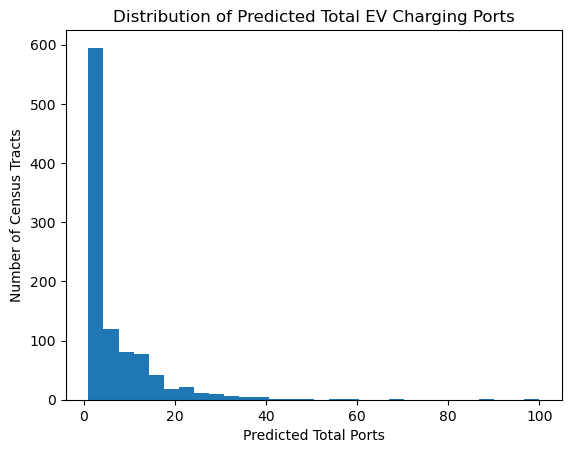

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(model_df["predicted_total_ports"], bins=30)
plt.xlabel("Predicted Total Ports")
plt.ylabel("Number of Census Tracts")
plt.title("Distribution of Predicted Total EV Charging Ports")
plt.show()

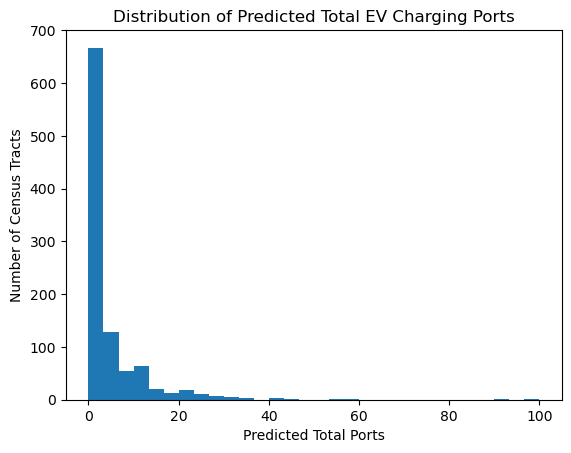

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(model_df["total_ports"], bins=30)
plt.xlabel("Predicted Total Ports")
plt.ylabel("Number of Census Tracts")
plt.title("Distribution of Predicted Total EV Charging Ports")
plt.show()

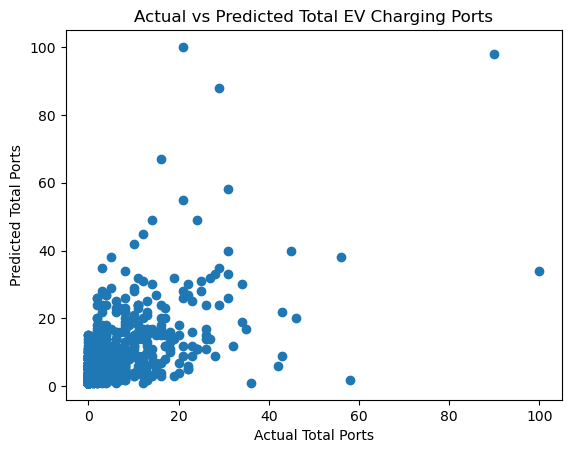

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(model_df["total_ports"], model_df["predicted_total_ports"])

plt.xlabel("Actual Total Ports")
plt.ylabel("Predicted Total Ports")
plt.title("Actual vs Predicted Total EV Charging Ports")

plt.show()

In [35]:
# Sum of actual total ports
sum_actual = model_df["total_ports"].sum()

# Sum of predicted total ports
sum_predicted = model_df["predicted_total_ports"].sum()

print("Total Actual Ports:", sum_actual)
print("Total Predicted Ports:", sum_predicted)
print("Overall Charging Gap:", sum_predicted - sum_actual)

Total Actual Ports: 4301.0
Total Predicted Ports: 6768.0
Overall Charging Gap: 2467.0


In [36]:
import geopandas as gpd
import os

def attach_predictions_to_master(state, model_df):

    state = state.upper()

    # -----------------------------
    # Paths
    # -----------------------------
    master_path = f"prediction_data/final/ev_master_{state}.geojson"
    output_dir = "prediction_data/predicted"
    os.makedirs(output_dir, exist_ok=True)

    if not os.path.exists(master_path):
        raise FileNotFoundError(f"{master_path} not found.")

    # -----------------------------
    # Load master GeoJSON
    # -----------------------------
    master_gdf = gpd.read_file(master_path)

    # Ensure GEOID consistency
    master_gdf["GEOID"] = master_gdf["GEOID"].astype(str).str.zfill(11)
    model_df["GEOID"] = model_df["GEOID"].astype(str).str.zfill(11)

    # Keep only prediction columns
    pred_cols = model_df[[
        "GEOID",
        "predicted_total_ports",
        "charging_gap"
    ]].copy()

    # -----------------------------
    # Merge
    # -----------------------------
    merged = master_gdf.merge(pred_cols, on="GEOID", how="left")

    merged["predicted_total_ports"] = merged["predicted_total_ports"].fillna(0)
    merged["charging_gap"] = merged["charging_gap"].fillna(0)

    # -----------------------------
    # Save
    # -----------------------------
    output_path = f"{output_dir}/ev_master_{state}_with_predictions.geojson"
    merged.to_file(output_path, driver="GeoJSON")

    print("Saved:", output_path)

    return merged

In [37]:
attach_predictions_to_master("OR", model_df)

2026-02-25 20:31:51,837 - INFO - Created 1,001 records


Saved: prediction_data/predicted/ev_master_OR_with_predictions.geojson


,GEOID,population,households,median_income,workers,vehicles_total,mean_commute_time,l2_ports,dcfc_ports,total_ports,...,high_wage_share,D1A,D3B,D4A,D1C,D2A_JPHH,NatWalkInd,geometry,predicted_total_ports,charging_gap
0,41019100000,3283.0,1286.0,70978.0,1289.0,1286.0,1025.0,4.0,0.0,4.0,...,0.572296,0.024468,1.510645,0.000000,0.010222,0.416389,4.555556,"POLYGON ((-123.20256 43.31449, -123.20254 43.3...",6.0,2.0
1,41053020306,2006.0,762.0,114231.0,1027.0,762.0,806.0,0.0,0.0,0.0,...,0.512739,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((-123.36479 44.83828, -123.36469 44.8...",2.0,2.0
2,41053005204,4419.0,1525.0,102462.0,2021.0,1525.0,1529.0,2.0,0.0,2.0,...,0.273463,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((-123.1152 44.92904, -123.11468 44.92...",1.0,-1.0
3,41019180000,4675.0,1921.0,61515.0,2241.0,1921.0,1783.0,2.0,0.0,2.0,...,0.375502,1.118011,53.121243,286.553333,0.549948,0.309942,10.166667,"POLYGON ((-123.37282 43.07053, -123.37278 43.0...",2.0,0.0
4,41019200000,4912.0,2135.0,47842.0,1958.0,2135.0,1368.0,2.0,20.0,22.0,...,0.564230,0.466440,25.987901,286.330000,0.580610,1.308112,9.000000,"POLYGON ((-123.51076 42.91495, -123.51075 42.9...",6.0,-16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,41029000502,5803.0,2411.0,45763.0,2388.0,2411.0,1949.0,3.0,0.0,3.0,...,0.470601,4.525540,133.194460,229.330000,9.094598,1.987842,15.166667,"POLYGON ((-122.87362 42.34114, -122.87347 42.3...",11.0,8.0
997,41029001002,4790.0,1692.0,67240.0,2487.0,1692.0,2303.0,1.0,0.0,1.0,...,0.556198,4.136794,170.054333,259.733333,4.979187,1.294052,15.833333,"POLYGON ((-122.94275 42.40606, -122.94245 42.4...",1.0,0.0
998,41029000403,4381.0,1785.0,101932.0,1812.0,1785.0,1364.0,1.0,0.0,1.0,...,0.324742,2.601768,71.550104,955.550000,0.409640,0.180773,11.666667,"POLYGON ((-122.84579 42.34322, -122.84579 42.3...",2.0,1.0
999,41029000405,4414.0,1611.0,63854.0,2372.0,1611.0,2023.0,2.0,0.0,2.0,...,0.428766,3.994286,130.837477,630.995000,3.049925,0.746886,15.500000,"POLYGON ((-122.87443 42.34684, -122.86913 42.3...",6.0,4.0
